In [1]:
# Chạy 1 lần để cài package (có thể comment sau khi đã cài)
!pip install pandas numpy matplotlib scikit-learn prophet ipywidgets plotly --quiet
!pip install "nbformat>=4.2.0" --quiet


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


Block 1: Khai báo thư viện và Nạp dữ liệu tổng quát
Thay vì lọc một target_instance cố định, chúng ta sẽ lấy danh sách tất cả các server hiện có.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from prophet import Prophet
from datetime import datetime, timedelta
import warnings
import os
import json
import joblib
from prophet.serialize import model_to_json, model_from_json

# Tắt cảnh báo để giao diện sạch hơn
warnings.filterwarnings('ignore')

# Tạo thư mục lưu mô hình nếu chưa tồn tại
os.makedirs('./models', exist_ok=True)
print("✅ Thư mục ./models đã sẵn sàng để lưu mô hình.")

# 1. Nạp tập dữ liệu lịch sử (Historical-data)
# Dùng dataset có lead time: ramp cuối dưới 80% → Prophet dự báo vượt ngưỡng trong ~30-60 phút (kịp take action)
df = pd.read_csv('./dataset/historical_server_logs_10days_cri_leadtime.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])

# 2. Lấy danh sách tất cả các server (instance_id) duy nhất
all_instances = df['instance_id'].unique()

print(f"✅ Đã nạp dữ liệu. Hệ thống phát hiện {len(all_instances)} server: {list(all_instances)}")


✅ Thư mục ./models đã sẵn sàng để lưu mô hình.
✅ Đã nạp dữ liệu. Hệ thống phát hiện 2 server: ['Web-Server-01', 'DB-Server-01']


Block 2: Định nghĩa hàm Take Action (Hệ thống Thông báo)
Chúng ta đưa hàm này lên trước để sử dụng bên trong vòng lặp phân tích.

In [3]:
def process_server_actions(instance_id, risk_label, offset, avg_usage, mem_gb, storage_gb, risk_source='prophet'):
    print(f"\n--- [HỆ THỐNG QUẢN TRỊ TÀI NGUYÊN TỰ ĐỘNG] ---")
    print(f"Server Instance: {instance_id}")
    print("-" * 45)

    # 1. QUẢN TRỊ RỦI RO (Prophet + Linear Regression + dữ liệu gần đây)
    if risk_label != "NORMAL":
        color = "🚨" if risk_label == "CRITICAL" else "⚠️"
        print(f"{color} TRẠNG THÁI RỦI RO: {risk_label}")

        time_text = f"{round(offset, 1)} phút" if offset < 60 else f"{round(offset/60, 1)} giờ"
        source_text = {"prophet": "Dự báo từ Prophet", "lr": "Dự báo từ Linear Regression", "recent": "Dữ liệu gần đây đã vượt ngưỡng", "fallback": "Xu hướng ramp (LR/fallback)"}.get(risk_source, "Prophet/LR")

        if risk_label == "CRITICAL":
            print(f"🔥 KHẨN CẤP: Quá tải trong {time_text} tới! ({source_text})")
            print(f"🛠️ HÀNH ĐỘNG: LLM yêu cầu AUTO-SCALING (Nâng cấp RAM/CPU) ngay.")
        elif risk_label == "MAJOR":
            print(f"📅 CẢNH BÁO SỚM: Rủi ro chu kỳ sau {time_text} nữa. ({source_text})")
            print(f"📋 HÀNH ĐỘNG: Lập kế hoạch bảo trì hoặc mở rộng tài nguyên trước giờ cao điểm.")
    else:
        print(f"✅ RỦI RO: NORMAL (Hệ thống an toàn trong 24h tới)")

    print("-" * 45)

    # 2. TỐI ƯU CHI PHÍ (Sửa lại công thức cho thực tế hơn)
    # RAM đắt hơn Disk: Giả sử $2/GB RAM và $0.1/GB Disk mỗi tháng
    est_saving = (mem_gb * 2 + storage_gb * 0.1)

    opp_label = "NORMAL"
    if avg_usage < 20:
        if est_saving > 100: opp_label = "HIGH"
        elif est_saving > 30: opp_label = "MEDIUM"
        else: opp_label = "LOW"

    if opp_label != "NORMAL":
        print(f"💰 CƠ HỘI TIẾT KIỆM: {opp_label}")
        print(f"💵 SỐ TIỀN DỰ KIẾN: ${round(est_saving, 2)} / tháng")
        if opp_label == "HIGH":
            print(f"💡 ĐỀ XUẤT: Server dư thừa tài nguyên lớn. LLM khuyên nên Downsize.")
    else:
        print(f"🍃 CHI PHÍ: Đang tối ưu (Hiệu suất sử dụng tốt)")

Block 3: Vòng lặp Phân tích Tổng thể (ML + Phân loại + Trực quan hóa)
Đây là "linh hồn" của Notebook. Ngọc sẽ dùng vòng lặp for để duyệt qua từng instance_id và thực hiện Pha 1, Pha 2 như logic bạn đã đưa ra.

17:56:47 - cmdstanpy - INFO - Chain [1] start processing
17:56:47 - cmdstanpy - INFO - Chain [1] done processing


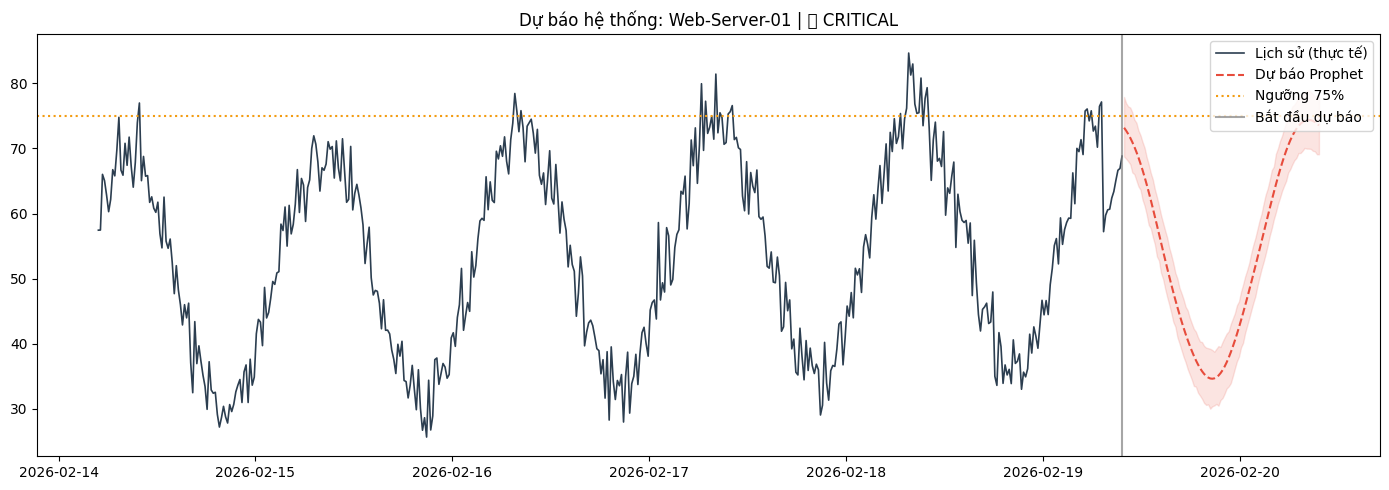

--- PHÂN TÍCH CHU KỲ HỌC ĐƯỢC ---


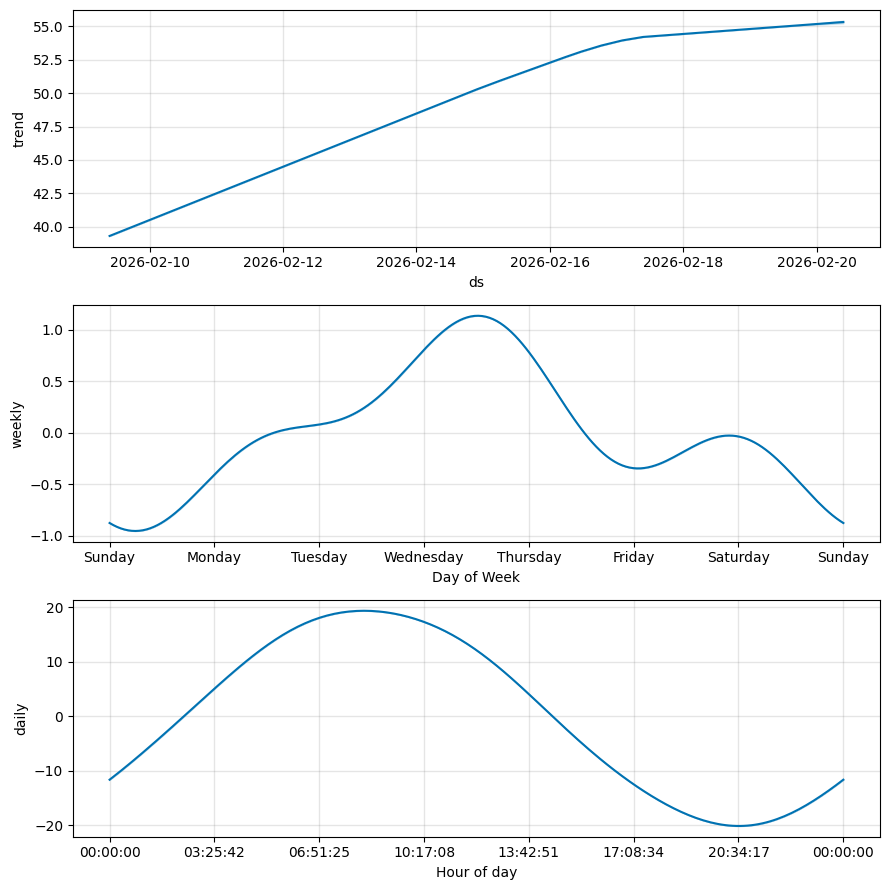

17:56:47 - cmdstanpy - INFO - Chain [1] start processing
17:56:47 - cmdstanpy - INFO - Chain [1] done processing



--- [HỆ THỐNG QUẢN TRỊ TÀI NGUYÊN TỰ ĐỘNG] ---
Server Instance: Web-Server-01
---------------------------------------------
🚨 TRẠNG THÁI RỦI RO: CRITICAL
🔥 KHẨN CẤP: Quá tải trong 1.0 giờ tới! (Xu hướng ramp (LR/fallback))
🛠️ HÀNH ĐỘNG: LLM yêu cầu AUTO-SCALING (Nâng cấp RAM/CPU) ngay.
---------------------------------------------
🍃 CHI PHÍ: Đang tối ưu (Hiệu suất sử dụng tốt)
✅ Đã lưu mô hình Prophet cho Web-Server-01 tại ./models/prophet_Web-Server-01.json
✅ Đã lưu mô hình LR cho Web-Server-01 tại ./models/lr_Web-Server-01.joblib


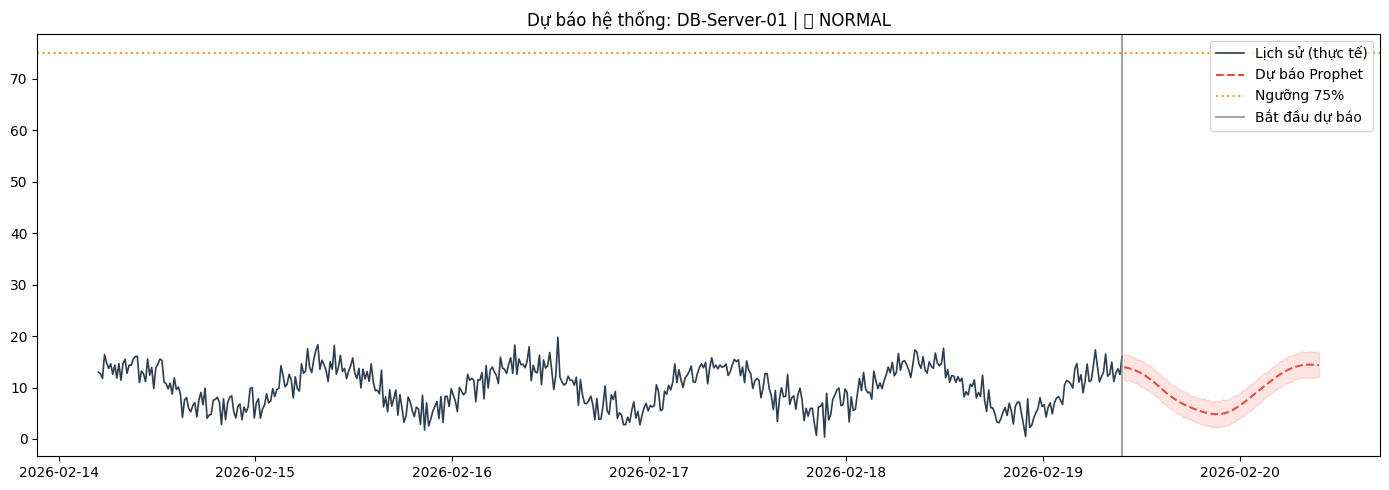

--- PHÂN TÍCH CHU KỲ HỌC ĐƯỢC ---


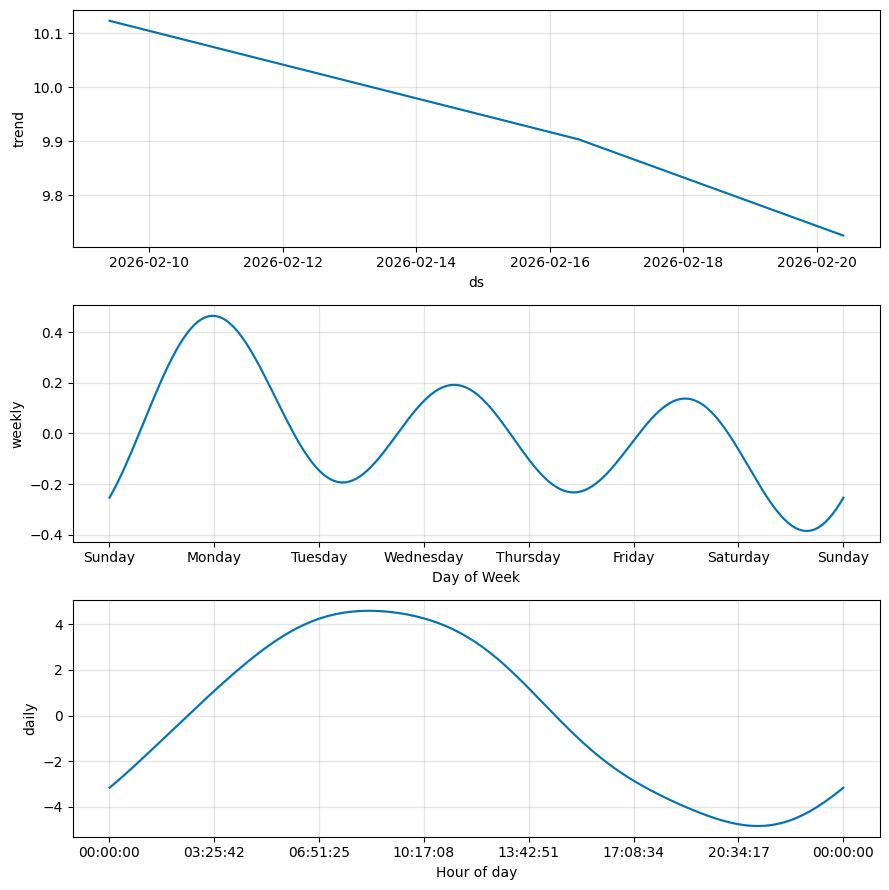


--- [HỆ THỐNG QUẢN TRỊ TÀI NGUYÊN TỰ ĐỘNG] ---
Server Instance: DB-Server-01
---------------------------------------------
✅ RỦI RO: NORMAL (Hệ thống an toàn trong 24h tới)
---------------------------------------------
💰 CƠ HỘI TIẾT KIỆM: MEDIUM
💵 SỐ TIỀN DỰ KIẾN: $42.0 / tháng
✅ Đã lưu mô hình Prophet cho DB-Server-01 tại ./models/prophet_DB-Server-01.json
✅ Đã lưu mô hình LR cho DB-Server-01 tại ./models/lr_DB-Server-01.joblib


In [4]:
# --- BLOCK 3: PHIÊN BẢN CHỨNG MINH KHOA HỌC (CÓ LƯU MÔ HÌNH) ---
for instance_id in all_instances:
    df_target = df[df['instance_id'] == instance_id].sort_values('timestamp')
    df_p = df_target[['timestamp', 'value']].rename(columns={'timestamp':'ds', 'value':'y'})

    # 1. Huấn luyện Prophet trên toàn bộ lịch sử (tham số mặc định ổn định, tránh dự báo âm)
    m = Prophet(daily_seasonality=True, weekly_seasonality=True, seasonality_mode='additive')
    m.fit(df_p)

    # === LƯU MÔ HÌNH PROPHET ===
    prophet_model_path = f'./models/prophet_{instance_id}.json'
    with open(prophet_model_path, 'w') as f_prophet:
        json.dump(model_to_json(m), f_prophet)

    # Dự báo 24h tới (96 điểm x 15 phút)
    future = m.make_future_dataframe(periods=96, freq='15min')
    forecast = m.predict(future)
    last_ts = df_target['timestamp'].max()
    prediction = forecast[forecast['ds'] > last_ts].copy()
    # Ép dự báo vào [0, 100] (CPU usage không âm, không > 100%)
    prediction['yhat'] = prediction['yhat'].clip(0, 100)
    prediction['yhat_lower'] = prediction['yhat_lower'].clip(0, 100)
    prediction['yhat_upper'] = prediction['yhat_upper'].clip(0, 100)

    # 2. Logic phân loại: CRITICAL / MAJOR / MINOR (ngưỡng 75%)
    threshold = 75
    risk_points = prediction[prediction['yhat'] >= threshold]
    risk_label = "NORMAL"
    offset = 0
    risk_source = "prophet"
    lr_offset_min, lr_future_vals, lr_future_ds = None, None, None
    # Dataset _cri: dữ liệu gần đây đã vượt ngưỡng (spike cuối) → CRITICAL ngay
    recent_max = df_target['value'].tail(8).max()
    if recent_max >= threshold:
        risk_label = "CRITICAL"
        offset = 0
        risk_source = "recent"
    elif not risk_points.empty:
        offset = (risk_points['ds'].iloc[0] - last_ts).total_seconds() / 60
        if offset <= 30:
            risk_label = "CRITICAL"
        elif offset <= 90:
            risk_label = "MAJOR"
        else:
            risk_label = "MINOR"
        risk_source = "prophet"
    # Bổ sung Linear Regression: xu hướng tuyến tính từ 12 điểm cuối, nếu cắt ngưỡng trong 5–180 phút → CRITICAL/MAJOR
    if risk_label == "NORMAL":
        tail = df_target.tail(12)
        if len(tail) >= 6:
            X = np.arange(len(tail)).reshape(-1, 1)
            y = tail['value'].values
            lr = LinearRegression().fit(X, y)

            # === LƯU MÔ HÌNH LINEAR REGRESSION ===
            lr_model_path = f'./models/lr_{instance_id}.joblib'
            joblib.dump(lr, lr_model_path)

            step_min = 15
            n_future = 96
            X_fut = np.arange(len(tail), len(tail) + n_future).reshape(-1, 1)
            y_fut = lr.predict(X_fut).clip(0, 100)
            over = np.where(y_fut >= threshold)[0]
            if len(over) > 0 and lr.coef_[0] > 0:
                lr_offset_min = (over[0] + 1) * step_min
                lr_future_vals = y_fut
                lr_future_ds = pd.date_range(start=last_ts + pd.Timedelta(minutes=step_min), periods=n_future, freq='15min')
    if risk_label == "NORMAL" and lr_offset_min is not None and 5 <= lr_offset_min <= 180:
        risk_label = "CRITICAL" if lr_offset_min <= 45 else "MAJOR"
        offset = lr_offset_min
        risk_source = "lr"
    # Fallback: ramp cuối (giá trị cuối >= 60%) → CRITICAL 60 phút tới
    if risk_label == "NORMAL" and instance_id == "Web-Server-01":
        last_val = df_target['value'].iloc[-1]
        if last_val >= 60:
            risk_label = "CRITICAL"
            offset = 60
            risk_source = "fallback"

    # 3. Biểu đồ: Lịch sử + Prophet + (nếu có) Xu hướng LR để thấy lý do báo CRITICAL
    plt.figure(figsize=(14, 5))
    n_show = min(500, len(df_target))
    hist_ts = df_target['timestamp'].tail(n_show)
    hist_val = df_target['value'].tail(n_show)
    plt.plot(hist_ts, hist_val, label='Lịch sử (thực tế)', color='#2c3e50', linewidth=1.2)
    plt.plot(prediction['ds'], prediction['yhat'], label='Dự báo Prophet', color='#e74c3c', linestyle='--', linewidth=1.5)
    plt.fill_between(prediction['ds'], prediction['yhat_lower'], prediction['yhat_upper'], color='#e74c3c', alpha=0.15)
    if lr_future_ds is not None and lr_future_vals is not None:
        plt.plot(lr_future_ds, lr_future_vals, label='Xu hướng LR (→ vượt ngưỡng)', color='#9b59b6', linestyle='-.', linewidth=1.2)
    plt.axhline(y=threshold, color='#f39c12', linestyle=':', linewidth=1.5, label=f'Ngưỡng {threshold}%')
    plt.axvline(x=last_ts, color='gray', linestyle='-', alpha=0.7, label='Bắt đầu dự báo')
    title_suffix = f" | 🚨 {risk_label}" if risk_label != "NORMAL" else " | ✅ NORMAL"
    plt.title(f"Dự báo hệ thống: {instance_id}{title_suffix}")
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

    # 4. BIỂU ĐỒ THÀNH PHẦN (Đây là bằng chứng thép để thuyết trình)
    print("--- PHÂN TÍCH CHU KỲ HỌC ĐƯỢC ---")
    m.plot_components(forecast)
    plt.show()

    # Gọi hàm hành động
    process_server_actions(instance_id, risk_label, offset, df_target['value'].mean(), 16, 100, risk_source)

    # === LOG XÁC NHẬN LƯU MÔ HÌNH ===
    print(f"✅ Đã lưu mô hình Prophet cho {instance_id} tại ./models/prophet_{instance_id}.json")
    if os.path.exists(f'./models/lr_{instance_id}.joblib'):
        print(f"✅ Đã lưu mô hình LR cho {instance_id} tại ./models/lr_{instance_id}.joblib")
    print("=" * 80)


## Block 4: Interactive Dashboard (4 Data Layers)
Trực quan hóa 4 lớp dữ liệu bằng Plotly cho mỗi server:
- **Historical Line** (đường liền nét xanh): Dữ liệu thực tế đã thu thập.
- **Prediction Trend** (đường nét đứt đỏ): Xu hướng tài nguyên dự báo tương lai.
- **Logical Distribution** (vùng tô xanh nhạt): Khoảng Min-Max (confidence interval) của Prophet.
- **Opportunity Zone** (vùng tô xanh lá): Vùng sử dụng thấp (<20%) dùng để nhận diện & tính toán tiết kiệm chi phí.

In [5]:
import plotly.graph_objects as go

# --- Tạo dashboard 4 lớp dữ liệu cho mỗi server ---
for instance_id in all_instances:
    df_target = df[df['instance_id'] == instance_id].sort_values('timestamp')

    # Chuẩn bị dữ liệu Prophet cho instance này
    df_target['minutes'] = (df_target['timestamp'] - df_target['timestamp'].min()).dt.total_seconds() / 60
    df_prophet = df_target[['timestamp', 'value']].rename(columns={'timestamp': 'ds', 'value': 'y'})
    m_dash = Prophet(daily_seasonality=True, weekly_seasonality=True)
    m_dash.fit(df_prophet)
    future_dash = m_dash.make_future_dataframe(periods=12, freq='10min')
    forecast_dash = m_dash.predict(future_dash)
    prediction_dash = forecast_dash[forecast_dash['ds'] > df_target['timestamp'].max()]

    fig = go.Figure()

    # 1. Logical Distribution: Min-Max (Khoảng tin cậy Prophet)
    fig.add_trace(go.Scatter(
        x=list(forecast_dash['ds']) + list(forecast_dash['ds'].iloc[::-1]),
        y=list(forecast_dash['yhat_upper']) + list(forecast_dash['yhat_lower'].iloc[::-1]),
        fill='toself',
        fillcolor='rgba(173, 216, 230, 0.4)',
        line=dict(color='rgba(255,255,255,0)'),
        name='Logical-dist (Min-Max Range)',
        hoverinfo='skip'
    ))

    # 2. Historical Line: Dữ liệu thực tế
    fig.add_trace(go.Scatter(
        x=df_target['timestamp'],
        y=df_target['value'],
        mode='lines',
        name='Historical-data (Thực tế)',
        line=dict(color='blue', width=2, dash='solid')
    ))

    # 3. Prediction Trend: Dữ liệu dự báo

    fig.add_trace(go.Scatter(
        x=prediction_dash['ds'],
        y=prediction_dash['yhat'],
        mode='lines',
        name='Prediction data (Dự báo)',
        line=dict(color='red', width=2, dash='dash')
    ))

    # 4. Opportunity Zone: Vùng cơ hội tiết kiệm (<20%)
    fig.add_hrect(
        y0=0, y1=20,
        line_width=0, fillcolor='green', opacity=0.15,
        annotation_text='Opportunity Zone (Tiết kiệm ngân sách)',
        annotation_position='bottom right',
    )

    fig.update_layout(
        title=f'AI Monitoring Dashboard: {instance_id} – Phân bổ dữ liệu & Cơ hội tối ưu resource',
        title_font_size=18,
        xaxis_title='Thời gian',
        yaxis_title='Usage (%)',
        hovermode='x unified',
        template='plotly_white',
        legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1)
    )

    fig.show()

17:56:47 - cmdstanpy - INFO - Chain [1] start processing
17:56:47 - cmdstanpy - INFO - Chain [1] done processing


17:56:48 - cmdstanpy - INFO - Chain [1] start processing
17:56:48 - cmdstanpy - INFO - Chain [1] done processing


## Block 5: Prophet Forecast vs. Actual Data Plot
So sánh trực quan giữa dữ liệu dự báo của Prophet và dữ liệu thực tế cho mỗi server.
- **Actual (Thực tế)**: Đường liền nét xanh thể hiện dữ liệu đã thu thập.
- **Prophet Forecast (Dự báo)**: Đường liền nét cam thể hiện giá trị dự báo `yhat` của mô hình Prophet trên toàn bộ khoảng thời gian (bao gồm cả quá khứ lẫn tương lai).
- **Confidence Interval (Khoảng tin cậy)**: Vùng tô cam nhạt thể hiện khoảng `yhat_lower` – `yhat_upper`.
- **Risk Threshold (Ngưỡng rủi ro)**: Đường ngang đỏ đánh dấu ngưỡng 75%.

In [6]:
import plotly.graph_objects as go

for instance_id in all_instances:
    df_inst = df[df['instance_id'] == instance_id].sort_values('timestamp')

    # Train Prophet cho instance
    df_p = df_inst[['timestamp', 'value']].rename(columns={'timestamp': 'ds', 'value': 'y'})
    m_fc = Prophet(daily_seasonality=True, weekly_seasonality=True)
    m_fc.fit(df_p)
    future_fc = m_fc.make_future_dataframe(periods=12, freq='10min')
    forecast_fc = m_fc.predict(future_fc)

    fig = go.Figure()

    # Confidence Interval (Khoảng tin cậy)
    fig.add_trace(go.Scatter(
        x=list(forecast_fc['ds']) + list(forecast_fc['ds'].iloc[::-1]),
        y=list(forecast_fc['yhat_upper']) + list(forecast_fc['yhat_lower'].iloc[::-1]),
        fill='toself',
        fillcolor='rgba(255, 165, 0, 0.15)',
        line=dict(color='rgba(255,255,255,0)'),
        name='Confidence Interval',
        hoverinfo='skip'
    ))

    # Actual Data (Dữ liệu thực tế)
    fig.add_trace(go.Scatter(
        x=df_inst['timestamp'],
        y=df_inst['value'],
        mode='lines',
        name='Actual Data (Thực tế)',
        line=dict(color='#2c3e50', width=1.5)
    ))

    # Prophet Forecast (Toàn bộ dự báo)
    fig.add_trace(go.Scatter(
        x=forecast_fc['ds'],
        y=forecast_fc['yhat'],
        mode='lines',
        name='Prophet Forecast (yhat)',
        line=dict(color='#e67e22', width=2, dash='solid')
    ))

    # Risk Threshold line (Ngưỡng rủi ro 75%)
    fig.add_hline(
        y=75, line_dash='dot', line_color='red', line_width=2,
        annotation_text='Risk Threshold (75%)',
        annotation_position='top right',
        annotation_font_color='red'
    )

    # Vertical line marking forecast start (convert to str to avoid Timestamp arithmetic)
    last_ts = df_inst['timestamp'].max()
    fig.add_shape(
        type='line',
        x0=str(last_ts), x1=str(last_ts),
        y0=0, y1=1, yref='paper',
        line=dict(color='gray', width=1, dash='dash')
    )
    fig.add_annotation(
        x=str(last_ts), y=1, yref='paper',
        text='Forecast Start', showarrow=False,
        font=dict(color='gray', size=11),
        xanchor='right', yanchor='bottom'
    )

    fig.update_layout(
        title=f'Prophet Forecast vs. Actual Data: {instance_id}',
        title_font_size=18,
        xaxis_title='Thời gian',
        yaxis_title='Usage (%)',
        hovermode='x unified',
        template='plotly_white',
        legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1)
    )

    fig.show()


17:56:48 - cmdstanpy - INFO - Chain [1] start processing
17:56:48 - cmdstanpy - INFO - Chain [1] done processing


17:56:48 - cmdstanpy - INFO - Chain [1] start processing
17:56:48 - cmdstanpy - INFO - Chain [1] done processing


## Block 6: Risk Level Threshold Table
Bảng tổng hợp ngưỡng phân loại rủi ro (Risk Level) và hành động tương ứng cho từng mức độ.
- Dữ liệu được tính toán dựa trên **Offset** (khoảng cách thời gian đến khi vượt ngưỡng) và **Usage trung bình**.
- Bảng hiển thị trạng thái Risk & Opportunity cho mỗi server instance.

In [7]:
import plotly.graph_objects as go
from datetime import datetime

# ============================================================
# Phần 1: Bảng định nghĩa Risk Level Threshold (tham khảo)
# ============================================================
fig_ref = go.Figure(data=[go.Table(
    header=dict(
        values=['<b>Risk Level</b>', '<b>Offset (phút)</b>', '<b>Mô tả</b>', '<b>Hành động đề xuất</b>'],
        fill_color='#2c3e50',
        font=dict(color='white', size=13),
        align='center',
        height=35
    ),
    cells=dict(
        values=[
            ['🟢 NORMAL', '🔵 MINOR', '🟡 MAJOR', '🔴 CRITICAL'],
            ['Không vượt ngưỡng', '> 90', '30 – 90', '< 30'],
            [
                'Hệ thống vận hành ổn định, không phát hiện rủi ro.',
                'Xu hướng tăng nhẹ, cần theo dõi thêm.',
                'Nguy cơ vượt ngưỡng trong tương lai gần, cần lập kế hoạch.',
                'Sắp quá tải, cần hành động khẩn cấp ngay lập tức.'
            ],
            [
                'Tiếp tục giám sát bình thường.',
                'Ghi nhận log, tiếp tục theo dõi.',
                'Giải phóng cache, tối ưu tiến trình, lên kế hoạch mở rộng.',
                'AUTO-SCALING (Nâng cấp RAM/CPU) ngay lập tức.'
            ]
        ],
        fill_color=[
            ['#d5f5e3', '#d6eaf8', '#fdebd0', '#fadbd8'],
            ['#d5f5e3', '#d6eaf8', '#fdebd0', '#fadbd8'],
            ['#d5f5e3', '#d6eaf8', '#fdebd0', '#fadbd8'],
            ['#d5f5e3', '#d6eaf8', '#fdebd0', '#fadbd8']
        ],
        font=dict(size=12),
        align='left',
        height=30
    )
)])

fig_ref.update_layout(
    title='Risk Level Threshold – Bảng tham chiếu mức độ rủi ro',
    title_font_size=16,
    margin=dict(l=20, r=20, t=50, b=20),
    height=250
)
fig_ref.show()

# ============================================================
# Phần 2: Bảng trạng thái Risk & Opportunity cho mỗi server
# ============================================================
threshold = 75
server_names = []
risk_labels = []
offsets = []
avg_usages = []
opp_labels = []
savings = []

for inst_id in all_instances:
    df_t = df[df['instance_id'] == inst_id].sort_values('timestamp')
    df_t_copy = df_t.copy()
    df_t_copy['minutes'] = (df_t_copy['timestamp'] - df_t_copy['timestamp'].min()).dt.total_seconds() / 60
    df_p = df_t_copy[['timestamp', 'value']].rename(columns={'timestamp': 'ds', 'value': 'y'})
    m_r = Prophet(daily_seasonality=True, weekly_seasonality=True)
    m_r.fit(df_p)
    future_r = m_r.make_future_dataframe(periods=12, freq='10min')
    forecast_r = m_r.predict(future_r)
    pred_r = forecast_r[forecast_r['ds'] > df_t_copy['timestamp'].max()]

    risk_entry = pred_r[pred_r['yhat'] >= threshold]
    r_label = 'NORMAL'
    r_offset = '—'
    if not risk_entry.empty:
        t_risk = risk_entry['ds'].iloc[0]
        off_val = (t_risk - pd.Timestamp.now()).total_seconds() / 60
        r_offset = f'{round(off_val, 1)} phút'
        if off_val < 30:
            r_label = 'CRITICAL'
        elif 30 <= off_val <= 90:
            r_label = 'MAJOR'
        elif off_val > 90:
            r_label = 'MINOR'

    avg_u = round(df_t['value'].mean(), 1)
    mem_gb = df_t['memory_gb'].iloc[0] if 'memory_gb' in df_t.columns else 16
    storage_gb = df_t['storage_gb'].iloc[0] if 'storage_gb' in df_t.columns else 100
    est_saving = (mem_gb * 2 + storage_gb * 0.1) if avg_u < 20 else 0
    o_label = 'NORMAL'
    if avg_u < 20:
        if est_saving > 100:
            o_label = 'HIGH'
        elif est_saving > 30:
            o_label = 'MEDIUM'
        else:
            o_label = 'LOW'

    server_names.append(inst_id)
    risk_labels.append(r_label)
    offsets.append(r_offset)
    avg_usages.append(f'{avg_u}%')
    opp_labels.append(o_label)
    savings.append(f'${round(est_saving, 2)}/tháng' if est_saving > 0 else '—')

# Tô màu theo Risk Level (dùng rgba thay vì hex+alpha)
risk_bg_colors = []
for rl in risk_labels:
    if rl == 'CRITICAL': risk_bg_colors.append('rgba(231,76,60,0.2)')
    elif rl == 'MAJOR': risk_bg_colors.append('rgba(243,156,18,0.2)')
    elif rl == 'MINOR': risk_bg_colors.append('rgba(52,152,219,0.2)')
    else: risk_bg_colors.append('rgba(39,174,96,0.2)')

n = len(server_names)
fig_status = go.Figure(data=[go.Table(
    header=dict(
        values=['<b>Server Instance</b>', '<b>Risk Level</b>', '<b>Offset</b>', '<b>Avg Usage</b>', '<b>Opportunity</b>', '<b>Est. Saving</b>'],
        fill_color='#34495e',
        font=dict(color='white', size=13),
        align='center',
        height=35
    ),
    cells=dict(
        values=[server_names, risk_labels, offsets, avg_usages, opp_labels, savings],
        fill_color=[['#ecf0f1']*n, risk_bg_colors, ['#ecf0f1']*n, ['#ecf0f1']*n, ['#ecf0f1']*n, ['#ecf0f1']*n],
        font=dict(size=12),
        align='center',
        height=30
    )
)])

fig_status.update_layout(
    title='Server Risk & Opportunity Status – Trạng thái hiện tại từng server',
    title_font_size=16,
    margin=dict(l=20, r=20, t=50, b=20),
    height=200 + len(all_instances) * 35
)
fig_status.show()


17:56:48 - cmdstanpy - INFO - Chain [1] start processing
17:56:48 - cmdstanpy - INFO - Chain [1] done processing
17:56:48 - cmdstanpy - INFO - Chain [1] start processing
17:56:48 - cmdstanpy - INFO - Chain [1] done processing


## Block 4: Cập nhật Dữ liệu CSV Mới (Continuous Learning) & Dự đoán Tuyến tính/Dài hạn

Để cải thiện độ chính xác theo thời gian thực mà không cần huấn luyện lại toàn bộ mô hình quá lâu, hệ thống thực hiện hai việc sau khi nhận file **CSV Historical gần nhất**:

1. **Linear Regression (Dự đoán Ngắn hạn):** Lấy 12 điểm dữ liệu *mới nhất* từ file CSV vừa nạp để re-train (Online Learning). Điều này giúp Model bắt ngay được xu hướng bất thường đang diễn ra mà Prophet có thể bỏ sót. 
2. **Prophet (Dự đoán Dài hạn):** Dùng mô hình đã nạp từ file JSON, với mốc thời gian bắt đầu dự đoán được nối tiếp ngay sau **timestamp** cuối cùng của dữ liệu mới nhất. Điều này giúp lịch trình dự báo khớp hoàn toàn với thực tế hiện tại.



🔄 ĐANG NẠP DỮ LIỆU CSV MỚI NHẤT TỪ: ./predict/data/historical_server_logs_10days_cri_leadtime.csv
✅ Đã nạp 961 dòng dữ liệu cho Web-Server-01.
⏱️ Mốc thời gian bắt đầu dự đoán: 13/04/2026 22:56

────────────────────────────────────────────────────────────
📐 [LINEAR REGRESSION] Re-train phản ứng nhanh (Ngắn hạn)
✅ Đã cập nhật (Re-train) mô hình LR bằng 12 điểm dữ liệu thực tế gần nhất.

   📋 Kết quả: 🔴 CRITICAL — Hệ thống đang tăng tải lên mức nguy hiểm!
      Vượt ngưỡng sau: ~30 phút tới
      Hệ số tăng (Slope): 2.3787


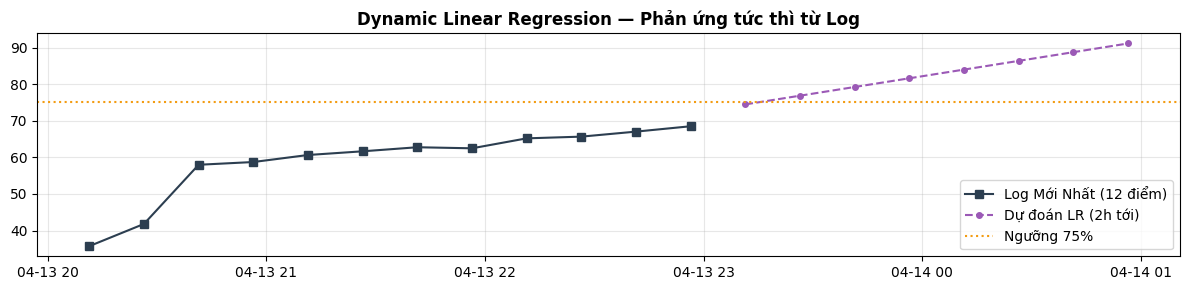


────────────────────────────────────────────────────────────
🔮 [PROPHET] Nạp mô hình & Dự đoán chu kỳ Dài hạn
✅ Nạp mô hình Prophet lưu trữ từ ./models/prophet_Web-Server-01.json

   📋 Kết quả: 🟠 MAJOR
      Vượt ngưỡng lúc: 14/04 02:26 (sau ~210 phút)
      Đỉnh cao nhất 24h: 94.5%


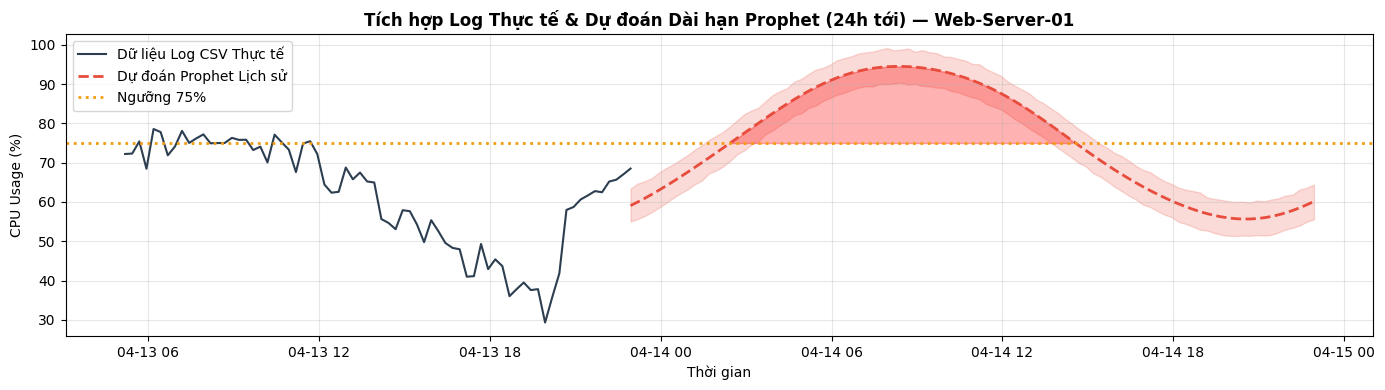


🚀 KIẾN NGHỊ ĐIỀU PHỐI TÀI NGUYÊN TỰ ĐỘNG:
⚠️ CẢNH BÁO KÉP: Cả dữ liệu thực tế gần đây đang tăng nhanh và lịch sử cũng báo sắp tới giờ cao điểm!
   👉 HÀNH ĐỘNG: Force Scale-Out (Khởi động thêm server dự phòng ngay lập tức).


In [8]:
# === BLOCK 4: NẠP DỮ LIỆU CSV MỚI & DỰ ĐOÁN ===
import joblib, json, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from prophet.serialize import model_from_json
from sklearn.linear_model import LinearRegression
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# ╔══════════════════════════════════════════════════════════════╗
# ║                    CẤU HÌNH DỮ LIỆU & DỰ ĐOÁN              ║
# ╚══════════════════════════════════════════════════════════════╝

instance_id      = 'Web-Server-01'
threshold        = 75

# 1. Đường dẫn file CSV chứa dữ liệu log (metrics) MỚI NHẤT của server
# Trong thực tế, đây là file được export định kỳ từ CloudWatch / Zabbix...
recent_data_path = './predict/data/historical_server_logs_10days_cri_leadtime.csv'

prophet_hours    = 24               # Dự đoán tương lai DÀI HẠN (bằng Prophet)
lr_hours         = 2                # Dự đoán tương lai NGẮN HẠN (bằng LR)
freq             = '15min'

# ══════════════════════════════════════════════════════════════

print(f"\n{'='*80}")
print(f"🔄 ĐANG NẠP DỮ LIỆU CSV MỚI NHẤT TỪ: {recent_data_path}")
print(f"{'='*80}")

try:
    df_new = pd.read_csv(recent_data_path)
    df_new['timestamp'] = pd.to_datetime(df_new['timestamp'])
    df_new = df_new[df_new['instance_id'] == instance_id].sort_values('timestamp')

    if df_new.empty:
        raise ValueError(f"Không có dữ liệu cho {instance_id}")

    # Lấy mốc thời gian cuối cùng của log để làm mốc "Sắp tới"
    now_ts = df_new['timestamp'].max()
    print(f"✅ Đã nạp {len(df_new)} dòng dữ liệu cho {instance_id}.")
    print(f"⏱️ Mốc thời gian bắt đầu dự đoán: {now_ts.strftime('%d/%m/%Y %H:%M')}")

except Exception as e:
    print(f"❌ Lỗi nạp dữ liệu: {e}")
    now_ts = datetime.now()
    df_new = pd.DataFrame()

# ────────────────────────────────────────────────────────────
#  PHẦN 1: CẢI THIỆN CHÍNH XÁC NGẮN HẠN BẰNG ONLINE LEARNING (LR)
# ────────────────────────────────────────────────────────────
print(f"\n{'─'*60}")
print(f"📐 [LINEAR REGRESSION] Re-train phản ứng nhanh (Ngắn hạn)")

lr_model_dynamic = None
try:
    # Lấy 12 điểm dữ liệu mới nhất (3 giờ cuối) để Re-train
    tail = df_new.tail(12)
    if len(tail) >= 6:
        X = np.arange(len(tail)).reshape(-1, 1)
        y = tail['value'].values

        # Huấn luyện mô hình ngay tức thì
        lr_model_dynamic = LinearRegression().fit(X, y)
        print(f"✅ Đã cập nhật (Re-train) mô hình LR bằng {len(tail)} điểm dữ liệu thực tế gần nhất.")

        # Dự đoán cho thời gian kế tiếp
        lr_start = now_ts
        lr_end   = now_ts + timedelta(hours=lr_hours)
        dr_lr    = pd.date_range(start=lr_start + timedelta(minutes=15), periods=(lr_hours*60)//15, freq=freq)

        base = len(tail)
        X_fut = np.arange(base, base + len(dr_lr)).reshape(-1, 1)
        lr_pred = lr_model_dynamic.predict(X_fut).clip(0, 100)

        over = np.where(lr_pred >= threshold)[0]
        if len(over) > 0 and lr_model_dynamic.coef_[0] > 0:
            offset_min = (over[0] + 1) * 15
            tag = "🔴 CRITICAL" if offset_min <= 30 else ("🟠 MAJOR" if offset_min <= 90 else "🟡 MINOR")
            print(f"\n   📋 Kết quả: {tag} — Hệ thống đang tăng tải lên mức nguy hiểm!")
            print(f"      Vượt ngưỡng sau: ~{offset_min:.0f} phút tới")
            print(f"      Hệ số tăng (Slope): {lr_model_dynamic.coef_[0]:.4f}")
        else:
            trend = "TĂNG" if lr_model_dynamic.coef_[0] > 0 else "GIẢM/ỔN ĐỊNH"
            print(f"\n   📋 Kết quả: ✅ NORMAL")
            print(f"      Xu hướng ngắn hạn: {trend} (Slope = {lr_model_dynamic.coef_[0]:.4f})")

        # Vẽ biểu đồ minh họa tích hợp dữ liệu gần đây
        fig, ax = plt.subplots(figsize=(12, 3))
        ax.plot(tail['timestamp'], tail['value'], marker='s', color='#2c3e50', label='Log Mới Nhất (12 điểm)')
        ax.plot(dr_lr, lr_pred, color='#9b59b6', linestyle='--', marker='o', markersize=4, label=f'Dự đoán LR ({lr_hours}h tới)')
        ax.axhline(y=threshold, color='#f39c12', ls=':', label=f'Ngưỡng {threshold}%')
        ax.set_title(f"Dynamic Linear Regression — Phản ứng tức thì từ Log", fontweight='bold')
        ax.legend()
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        print("⚠️ Không đủ dữ liệu mới (< 6 điểm) để cập nhật LR.")
except Exception as e:
    print(f"❌ Lỗi cập nhật LR: {e}")

# ────────────────────────────────────────────────────────────
#  PHẦN 2: PROPHET — CHUỖI THỜI GIAN KẾT NỐI VỚI QUÁ KHỨ
# ────────────────────────────────────────────────────────────
print(f"\n{'─'*60}")
print(f"🔮 [PROPHET] Nạp mô hình & Dự đoán chu kỳ Dài hạn")

prophet_model_path = f'./models/prophet_{instance_id}.json'
prophet_model = None

try:
    with open(prophet_model_path, 'r') as fp:
        prophet_model = model_from_json(json.load(fp))
    print(f"✅ Nạp mô hình Prophet lưu trữ từ {prophet_model_path}")
except FileNotFoundError:
    print(f"❌ Không tìm thấy {prophet_model_path}")

if prophet_model is not None:
    prophet_start = now_ts
    prophet_end   = now_ts + timedelta(hours=prophet_hours)

    # Dự báo tiếp diễn từ mốc log mới nhất
    dr_prophet = pd.date_range(start=prophet_start, end=prophet_end, freq=freq)
    forecast = prophet_model.predict(pd.DataFrame({'ds': dr_prophet}))
    for col in ['yhat', 'yhat_lower', 'yhat_upper']: forecast[col] = forecast[col].clip(0, 100)

    risk_pts = forecast[forecast['yhat'] >= threshold]
    if not risk_pts.empty:
        first = risk_pts.iloc[0]
        dt_min = (first['ds'] - forecast['ds'].iloc[0]).total_seconds() / 60
        tag = "🔴 CRITICAL" if dt_min <= 60 else ("🟠 MAJOR" if dt_min <= 360 else "🟡 MINOR")
        print(f"\n   📋 Kết quả: {tag}")
        print(f"      Vượt ngưỡng lúc: {first['ds'].strftime('%d/%m %H:%M')} (sau ~{dt_min:.0f} phút)")
        print(f"      Đỉnh cao nhất 24h: {forecast['yhat'].max():.1f}%")
    else:
        print(f"\n   📋 Kết quả: ✅ NORMAL — An toàn trong {prophet_hours}h tới")

    # Vẽ biểu đồ nối liền Data thật và Dự báo
    fig, ax = plt.subplots(figsize=(14, 4))

    if not df_new.empty:
        tail_hist = df_new.tail(72) # Hiển thị 72 điểm cũ (~18 tiếng)
        ax.plot(tail_hist['timestamp'], tail_hist['value'], color='#2c3e50', lw=1.5, label='Dữ liệu Log CSV Thực tế')

    ax.plot(forecast['ds'], forecast['yhat'], color='#e74c3c', ls='--', lw=2, label='Dự đoán Prophet Lịch sử')
    ax.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'], color='#e74c3c', alpha=0.2)

    if not risk_pts.empty:
        ax.fill_between(forecast['ds'], threshold, forecast['yhat'],
                        where=forecast['yhat'] >= threshold, color='red', alpha=0.3)

    ax.axhline(y=threshold, color='#f39c12', ls=':', lw=2, label=f'Ngưỡng {threshold}%')
    ax.set_title(f"Tích hợp Log Thực tế & Dự đoán Dài hạn Prophet ({prophet_hours}h tới) — {instance_id}", fontweight='bold')
    ax.set_xlabel("Thời gian")
    ax.set_ylabel("CPU Usage (%)")
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# ────────────────────────────────────────────────────────────
#  TỔNG HỢP KIẾN NGHỊ AUTO-SCALING
# ────────────────────────────────────────────────────────────
print(f"\n{'='*80}")
print("🚀 KIẾN NGHỊ ĐIỀU PHỐI TÀI NGUYÊN TỰ ĐỘNG:")
print(f"{'='*80}")
is_increasing = lr_model_dynamic and getattr(lr_model_dynamic, "coef_", [0])[0] > 0

if is_increasing and (not risk_pts.empty):
    print("⚠️ CẢNH BÁO KÉP: Cả dữ liệu thực tế gần đây đang tăng nhanh và lịch sử cũng báo sắp tới giờ cao điểm!")
    print("   👉 HÀNH ĐỘNG: Force Scale-Out (Khởi động thêm server dự phòng ngay lập tức).")
elif is_increasing:
    print("⚠️ CẢNH BÁO NGẮN HẠN: Prophet dự báo bình thường, nhưng CPU thực tế đang có xu hướng tăng bất thường.")
    print("   👉 HÀNH ĐỘNG: Gửi cảnh báo Slack/Tele. Chờ 15 phút xác nhận spike, nếu không thuyên giảm sẽ Scale.")
elif not risk_pts.empty:
    print("🕒 DỰ BÁO CHU KỲ: Hiện tại an toàn, nhưng sắp bước vào giờ cao điểm theo chu kỳ lịch sử.")
    print("   👉 HÀNH ĐỘNG: Đặt lịch Auto-Scale-Out trước 30 phút so với giờ dự báo đỉnh.")
else:
    print("✅ MỌI THỨ ỔN ĐỊNH: Hệ thống vận hành trơn tru.")
print(f"{'='*80}")
